# Notebook 04 — Regularización con Ridge

En este notebook estudiaremos cómo Ridge controla la complejidad de una regresión lineal mediante una penalización sobre los coeficientes.

## Objetivos

Al finalizar el notebook deberías ser capaz de:

- explicar la idea de regularización;
- comparar regresión lineal ordinaria y Ridge;
- interpretar el hiperparámetro \(\alpha\);
- visualizar la contracción de coeficientes;
- comprender por qué el escalamiento es importante;
- utilizar `Pipeline` para evitar errores de preprocesamiento;
- analizar el compromiso entre sesgo y varianza;
- seleccionar preliminarmente un valor de regularización.

Utilizaremos datos sintéticos con variables correlacionadas y variables poco informativas.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.options.display.float_format = "{:,.4f}".format


## 2. Generación de datos con colinealidad

Construiremos variables correlacionadas para observar la inestabilidad de los coeficientes.

La variable objetivo se genera a partir de unas pocas señales reales, mientras que otras variables son redundantes o contienen ruido.

In [2]:
n_samples = 180

latent_1 = rng.normal(size=n_samples)
latent_2 = rng.normal(size=n_samples)

X = pd.DataFrame({
    "x1": latent_1 + rng.normal(0, 0.08, n_samples),
    "x2": latent_1 + rng.normal(0, 0.08, n_samples),
    "x3": 2.0 * latent_1 + rng.normal(0, 0.12, n_samples),
    "x4": latent_2 + rng.normal(0, 0.10, n_samples),
    "x5": latent_2 + rng.normal(0, 0.10, n_samples),
    "x6": rng.normal(size=n_samples),
    "x7": rng.normal(size=n_samples),
    "x8": rng.normal(size=n_samples),
})

true_signal = (
    4.0 * X["x1"]
    - 3.0 * X["x4"]
    + 1.5 * X["x6"]
)

y = true_signal + rng.normal(0, 2.0, n_samples)

print(X.shape)
X.head()


(180, 8)


,x1,x2,x3,x4,x5,x6,x7,x8
0,0.2925,0.1698,0.5979,1.3450,1.3304,0.9993,-0.6646,0.5774
1,-1.0093,-1.1061,-1.9446,0.2296,0.2043,0.0974,0.3606,0.0466
2,0.8304,0.7703,1.2272,-0.4257,-0.3677,0.7958,-1.3907,0.7619
3,0.8559,0.9262,1.7015,1.2651,1.1125,-0.4472,1.4387,1.1755
4,-1.9610,-1.9713,-4.0128,0.3665,0.4398,-0.0496,-0.1440,0.1924


In [3]:
correlation_matrix = X.corr()
correlation_matrix.round(3)


,x1,x2,x3,x4,x5,x6,x7,x8
x1,1.0000,0.9910,0.9930,-0.0640,-0.0520,0.0910,0.0760,0.0000
x2,0.9910,1.0000,0.9930,-0.0740,-0.0630,0.0670,0.0810,-0.0120
x3,0.9930,0.9930,1.0000,-0.0730,-0.0620,0.0820,0.0870,-0.0040
x4,-0.0640,-0.0740,-0.0730,1.0000,0.9910,0.0810,0.0010,-0.0780
x5,-0.0520,-0.0630,-0.0620,0.9910,1.0000,0.0830,0.0030,-0.0840
x6,0.0910,0.0670,0.0820,0.0810,0.0830,1.0000,-0.0220,0.0110
x7,0.0760,0.0810,0.0870,0.0010,0.0030,-0.0220,1.0000,0.0440
x8,0.0000,-0.0120,-0.0040,-0.0780,-0.0840,0.0110,0.0440,1.0000


Las variables \(x_1,x_2,x_3\) contienen información muy parecida. Lo mismo ocurre con \(x_4,x_5\).

Cuando varias variables son fuertemente correlacionadas, OLS puede repartir la señal entre ellas de forma inestable.

## 3. Split de entrenamiento y prueba

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")


Train: (126, 8)
Test: (54, 8)


## 4. Modelo base: regresión lineal ordinaria

In [5]:
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

ols_train_pred = ols_model.predict(X_train)
ols_test_pred = ols_model.predict(X_test)

ols_results = pd.DataFrame({
    "Métrica": ["RMSE train", "RMSE test", "R² test"],
    "Valor": [
        mean_squared_error(y_train, ols_train_pred) ** 0.5,
        mean_squared_error(y_test, ols_test_pred) ** 0.5,
        r2_score(y_test, ols_test_pred),
    ],
})

ols_results


,Métrica,Valor
0,RMSE train,1.7971
1,RMSE test,2.3462
2,R² test,0.8337


In [6]:
ols_coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente OLS": ols_model.coef_,
})

ols_coefficients


,Variable,Coeficiente OLS
0,x1,1.2376
1,x2,-0.7323
2,x3,1.7205
3,x4,-5.7246
4,x5,2.3901
5,x6,1.3543
6,x7,-0.1025
7,x8,0.0831


## 5. Función objetivo de Ridge

Ridge minimiza:

\[
\sum_{i=1}^{n}(y_i-\widehat{y}_i)^2
+
\alpha\sum_{j=1}^{p}\beta_j^2.
\]

La primera parte mide ajuste.  
La segunda penaliza coeficientes grandes.

- \(\alpha=0\): Ridge coincide con OLS.
- \(\alpha\) pequeño: penalización débil.
- \(\alpha\) grande: coeficientes más cercanos a cero.

En las notas puede aparecer \(\lambda\). `scikit-learn` utiliza el nombre `alpha`.

## 6. Ridge dentro de un `Pipeline`

Ridge depende de la escala porque penaliza directamente la magnitud de los coeficientes.

Por eso combinaremos:

1. `StandardScaler`;
2. `Ridge`.

El escalador se ajusta únicamente con entrenamiento.

In [7]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0)),
])

ridge_pipeline.fit(X_train, y_train)

ridge_train_pred = ridge_pipeline.predict(X_train)
ridge_test_pred = ridge_pipeline.predict(X_test)

ridge_results = pd.DataFrame({
    "Métrica": ["RMSE train", "RMSE test", "R² test"],
    "Valor": [
        mean_squared_error(y_train, ridge_train_pred) ** 0.5,
        mean_squared_error(y_test, ridge_test_pred) ** 0.5,
        r2_score(y_test, ridge_test_pred),
    ],
})

ridge_results


,Métrica,Valor
0,RMSE train,1.8169
1,RMSE test,2.2500
2,R² test,0.8471


In [8]:
ridge_coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente Ridge estandarizado": (
        ridge_pipeline.named_steps["ridge"].coef_
    ),
})

ridge_coefficients


,Variable,Coeficiente Ridge estandarizado
0,x1,1.2718
1,x2,0.1913
2,x3,1.9089
3,x4,-3.8237
4,x5,0.6627
5,x6,1.4816
6,x7,-0.0752
7,x8,0.0969


Los coeficientes anteriores corresponden a variables estandarizadas. Su interpretación es distinta de la de OLS sobre las unidades originales.

Sirven especialmente para analizar la magnitud relativa y la contracción producida por la penalización.

## 7. Comparación de diferentes valores de \(\alpha\)

In [9]:
alphas = [0.0, 0.01, 0.1, 1, 10, 100, 1000]
alpha_results = []
coefficient_paths = []

for alpha in alphas:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha)),
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    alpha_results.append({
        "alpha": alpha,
        "rmse_train": mean_squared_error(
            y_train,
            train_pred,
        ) ** 0.5,
        "rmse_test": mean_squared_error(
            y_test,
            test_pred,
        ) ** 0.5,
        "r2_test": r2_score(y_test, test_pred),
    })

    coefficient_paths.append({
        "alpha": alpha,
        **{
            variable: coefficient
            for variable, coefficient in zip(
                X.columns,
                model.named_steps["ridge"].coef_,
            )
        },
    })

alpha_results_df = pd.DataFrame(alpha_results)
coefficient_paths_df = pd.DataFrame(coefficient_paths)

alpha_results_df


,alpha,rmse_train,rmse_test,r2_test
0,0.0000,1.7971,2.3462,0.8337
1,0.0100,1.7971,2.3442,0.8340
2,0.1000,1.7976,2.3282,0.8363
3,1.0000,1.8169,2.2500,0.8471
4,10.0000,1.8859,2.1864,0.8556
5,100.0000,2.3063,2.5945,0.7967
6,"1,000.0000",4.2641,4.6074,0.3589


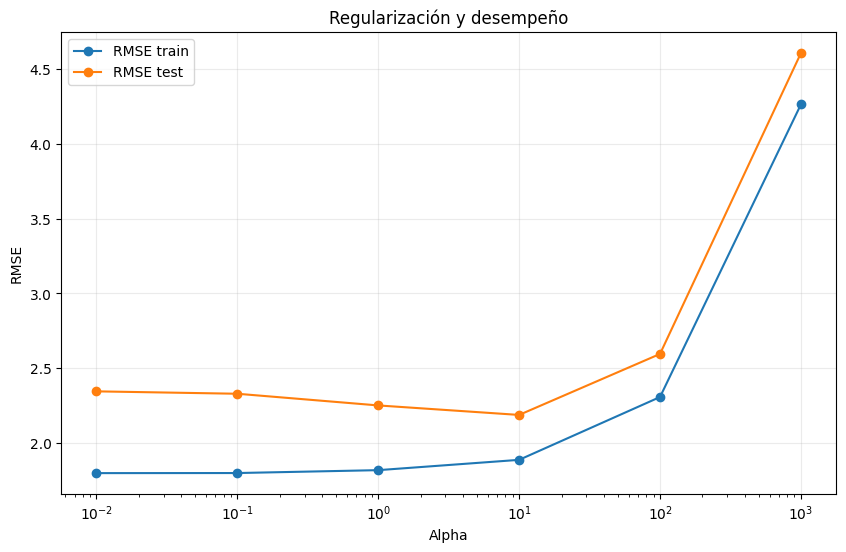

In [10]:
plt.figure(figsize=(10, 6))

positive_alpha_results = alpha_results_df[
    alpha_results_df["alpha"] > 0
]

plt.plot(
    positive_alpha_results["alpha"],
    positive_alpha_results["rmse_train"],
    marker="o",
    label="RMSE train",
)

plt.plot(
    positive_alpha_results["alpha"],
    positive_alpha_results["rmse_test"],
    marker="o",
    label="RMSE test",
)

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Regularización y desempeño")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


Conforme aumenta \(\alpha\):

- el modelo pierde flexibilidad;
- el error de entrenamiento suele aumentar;
- el error de prueba puede disminuir inicialmente;
- si la penalización es excesiva, aparece underfitting.

## 8. Trayectoria de los coeficientes

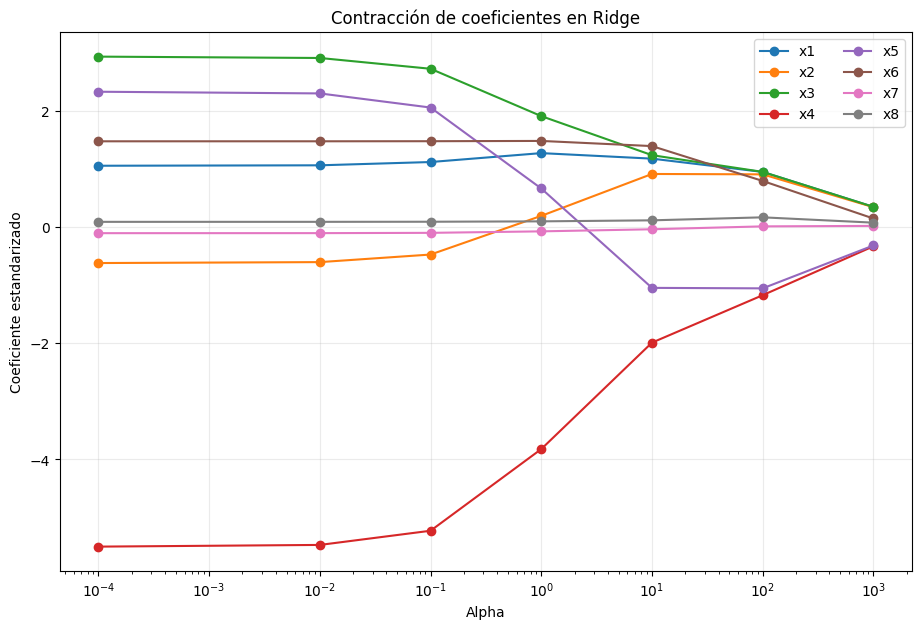

In [11]:
plt.figure(figsize=(11, 7))

for variable in X.columns:
    plt.plot(
        coefficient_paths_df["alpha"].replace(0, 1e-4),
        coefficient_paths_df[variable],
        marker="o",
        label=variable,
    )

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coeficiente estandarizado")
plt.title("Contracción de coeficientes en Ridge")
plt.legend(ncol=2)
plt.grid(alpha=0.25)
plt.show()


Ridge contrae los coeficientes de forma continua.

A diferencia de Lasso, normalmente no los lleva exactamente a cero. Por eso Ridge no realiza selección estricta de variables.

## 9. Comparación resumida entre OLS y Ridge

In [12]:
comparison = pd.DataFrame({
    "Modelo": ["OLS", "Ridge alpha=1"],
    "RMSE train": [
        mean_squared_error(y_train, ols_train_pred) ** 0.5,
        mean_squared_error(y_train, ridge_train_pred) ** 0.5,
    ],
    "RMSE test": [
        mean_squared_error(y_test, ols_test_pred) ** 0.5,
        mean_squared_error(y_test, ridge_test_pred) ** 0.5,
    ],
    "R² test": [
        r2_score(y_test, ols_test_pred),
        r2_score(y_test, ridge_test_pred),
    ],
})

comparison


,Modelo,RMSE train,RMSE test,R² test
0,OLS,1.7971,2.3462,0.8337
1,Ridge alpha=1,1.8169,2.2500,0.8471


Ridge puede aceptar un ajuste ligeramente peor en entrenamiento a cambio de mayor estabilidad y mejor generalización.

No siempre superará a OLS. Su utilidad depende de:

- colinealidad;
- cantidad de variables;
- tamaño de muestra;
- nivel de ruido;
- valor de \(\alpha\).

## 10. ¿Qué ocurre si no escalamos?

In [13]:
X_different_scales = X.copy()
X_different_scales["x6"] = X_different_scales["x6"] * 1_000

X_train_scale, X_test_scale, y_train_scale, y_test_scale = train_test_split(
    X_different_scales,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
)

ridge_without_scaling = Ridge(alpha=10)
ridge_without_scaling.fit(X_train_scale, y_train_scale)

ridge_with_scaling = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10)),
])
ridge_with_scaling.fit(X_train_scale, y_train_scale)

scale_comparison = pd.DataFrame({
    "Modelo": ["Ridge sin escalar", "Ridge con escalamiento"],
    "RMSE test": [
        mean_squared_error(
            y_test_scale,
            ridge_without_scaling.predict(X_test_scale),
        ) ** 0.5,
        mean_squared_error(
            y_test_scale,
            ridge_with_scaling.predict(X_test_scale),
        ) ** 0.5,
    ],
})

scale_comparison


,Modelo,RMSE test
0,Ridge sin escalar,2.1779
1,Ridge con escalamiento,2.1864


Sin escalamiento, una variable medida en unidades grandes puede recibir una penalización efectiva distinta de otra medida en unidades pequeñas.

El escalamiento hace que la penalización sea comparable entre variables.

## 11. Estabilidad ante diferentes muestras

Una motivación importante de Ridge es reducir la variabilidad de los coeficientes cuando hay colinealidad.

In [14]:
n_repetitions = 150
ols_coefficient_samples = []
ridge_coefficient_samples = []

for seed in range(n_repetitions):
    X_sample_train, _, y_sample_train, _ = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=seed,
    )

    ols = LinearRegression()
    ols.fit(X_sample_train, y_sample_train)
    ols_coefficient_samples.append(ols.coef_)

    ridge = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10)),
    ])
    ridge.fit(X_sample_train, y_sample_train)
    ridge_coefficient_samples.append(
        ridge.named_steps["ridge"].coef_
    )

ols_coefficient_samples = np.vstack(ols_coefficient_samples)
ridge_coefficient_samples = np.vstack(ridge_coefficient_samples)

stability_table = pd.DataFrame({
    "Variable": X.columns,
    "Desv. coeficiente OLS": ols_coefficient_samples.std(axis=0),
    "Desv. coeficiente Ridge": ridge_coefficient_samples.std(axis=0),
})

stability_table


,Variable,Desv. coeficiente OLS,Desv. coeficiente Ridge
0,x1,1.0072,0.0983
1,x2,0.8553,0.0928
2,x3,0.5057,0.0746
3,x4,0.8270,0.1085
4,x5,0.8047,0.1061
5,x6,0.1092,0.1202
6,x7,0.0981,0.0919
7,x8,0.1128,0.1055


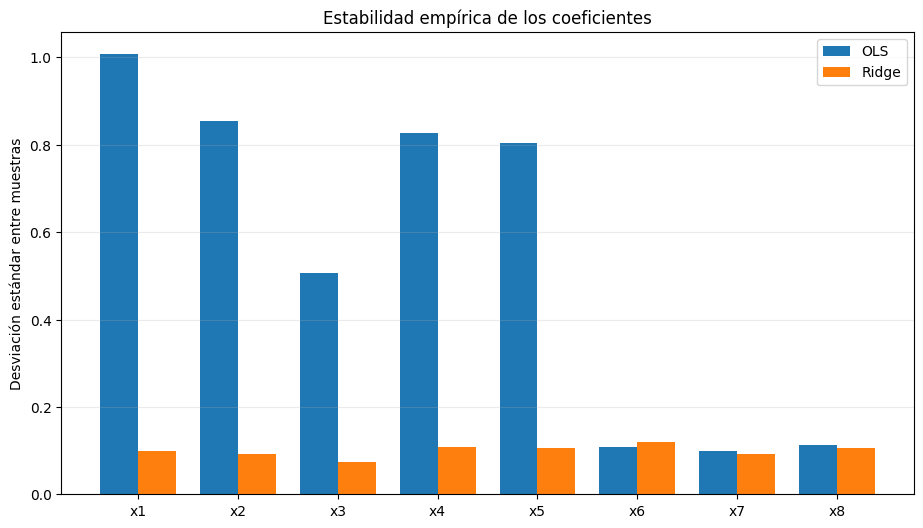

In [15]:
positions = np.arange(len(X.columns))
width = 0.38

plt.figure(figsize=(11, 6))

plt.bar(
    positions - width / 2,
    stability_table["Desv. coeficiente OLS"],
    width=width,
    label="OLS",
)

plt.bar(
    positions + width / 2,
    stability_table["Desv. coeficiente Ridge"],
    width=width,
    label="Ridge",
)

plt.xticks(positions, X.columns)
plt.ylabel("Desviación estándar entre muestras")
plt.title("Estabilidad empírica de los coeficientes")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()


La comparación debe interpretarse con cuidado porque los coeficientes Ridge están expresados sobre variables estandarizadas. El objetivo principal es observar su variabilidad relativa entre muestras.

En presencia de colinealidad, Ridge suele producir estimaciones más estables.

## 12. Selección preliminar de \(\alpha\)

En este notebook observamos el desempeño sobre test únicamente con fines didácticos.

En un proyecto real:

1. se reserva el test;
2. se selecciona \(\alpha\) mediante validación cruzada;
3. se ajusta el modelo final;
4. se evalúa una sola vez sobre test.

La validación cruzada se estudiará en un notebook posterior.

In [16]:
best_alpha_row = alpha_results_df.loc[
    alpha_results_df["rmse_test"].idxmin()
]

best_alpha_row.to_frame(name="Resultado")


,Resultado
alpha,10.0000
rmse_train,1.8859
rmse_test,2.1864
r2_test,0.8556


## 13. Errores frecuentes

1. Aplicar Ridge sin escalar variables numéricas.
2. Ajustar el escalador antes de separar los datos.
3. Elegir \(\alpha\) usando repetidamente el test.
4. Interpretar coeficientes estandarizados como si estuvieran en unidades originales.
5. Suponer que una penalización mayor siempre mejora el modelo.
6. Pensar que Ridge elimina variables.
7. Ignorar que el intercepto normalmente no se penaliza en `scikit-learn`.

## 14. Experimentos sugeridos

### Experimento 1

Cambia el ruido de la variable objetivo.  
¿En qué condiciones Ridge obtiene una ventaja mayor?

### Experimento 2

Reduce el tamaño de muestra a 40 observaciones.  
Compara la estabilidad de OLS y Ridge.

### Experimento 3

Agrega 50 variables completamente aleatorias.  
Observa el desempeño y los coeficientes.

### Experimento 4

Prueba valores de \(\alpha\) en una malla más fina:

```python
np.logspace(-4, 4, 50)
```

### Experimento 5

Elimina las variables correlacionadas y repite el análisis.  
¿Ridge sigue ofreciendo la misma ventaja?

### Experimento 6

Compara Ridge con Lasso y observa cuáles coeficientes llegan exactamente a cero.

## 15. Resumen

En este notebook:

- construimos datos con colinealidad;
- ajustamos OLS y Ridge;
- utilizamos escalamiento dentro de un `Pipeline`;
- estudiamos el efecto de \(\alpha\);
- visualizamos la trayectoria de coeficientes;
- analizamos el compromiso sesgo-varianza;
- observamos la estabilidad de los coeficientes;
- discutimos el procedimiento correcto para seleccionar regularización.

Ridge sacrifica parte del ajuste en entrenamiento para controlar la magnitud de los coeficientes y mejorar la estabilidad del modelo.